## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [14]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__compare_psd_stream import __compare_psd_stream

## Configurations

In [2]:
config = {}

config['path_to_inv'] = "/home/andbro/kilauea-data/GEORG/stationxml/"

config['path_to_data'] = "/home/andbro/kilauea-data/GEORG/data/"

config['path_to_figs'] = "/home/andbro/kilauea-data/GEORG/figures/"

config['tbeg'] = obs.UTCDateTime("2024-12-16 22:00")
config['tend'] = obs.UTCDateTime("2024-12-17 02:00")


### Seismometer Data

In [3]:
st_seis = __read_sds(config['path_to_data'], "XN.BONN..HH*", config['tbeg'], config['tend'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN.xml')

print(st_seis)

3 Trace(s) in Stream:
XN.BONN..HHE | 2024-12-16T22:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 2880001 samples
XN.BONN..HHN | 2024-12-16T22:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 2880001 samples
XN.BONN..HHZ | 2024-12-16T22:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 2880001 samples


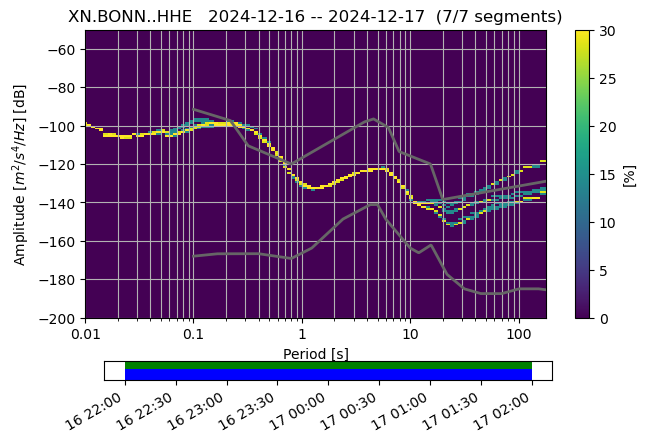

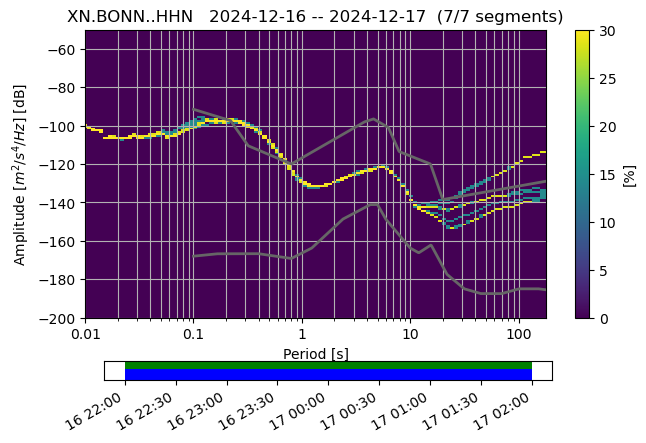

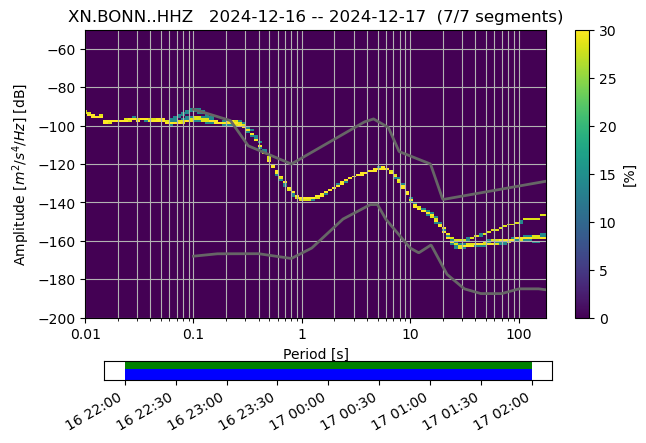

In [4]:
for tr in st_seis:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()

### Tiltmeter Data

In [5]:
head = ["time", "north", "east", "X1", "X2", "pressure", "X3", "X4", "X5", "X6"]

tilt = pd.read_csv(config['path_to_data']+"LGMBoxmessung12_16.csv", delimiter=";", names=head)

starttime = obs.UTCDateTime(tilt.time[0])
print(starttime)

mean_dt = tilt.time.diff().mean()
print(mean_dt)

2024-12-16T16:36:15.716615Z
1.0550388852159318


In [6]:
# plt.plot(tilt.time.diff())

In [7]:
st_tilt = __read_sds(config['path_to_data'], "XX.TILT..LA*", config['tbeg'], config['tend'])

print(st_tilt)

2 Trace(s) in Stream:
XX.TILT..LAE | 2024-12-16T22:00:00.037528Z - 2024-12-17T02:00:00.263173Z | 0.9 Hz, 13650 samples
XX.TILT..LAN | 2024-12-16T22:00:00.037528Z - 2024-12-17T02:00:00.263173Z | 0.9 Hz, 13650 samples


In [8]:
for tr in st_tilt:
    tr.data *= 9.81

### RaspShake Data

In [9]:
st_rasp = __read_sds(config['path_to_data'], "AM.RACB0.00.EH*", config['tbeg'], config['tend'])

inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")


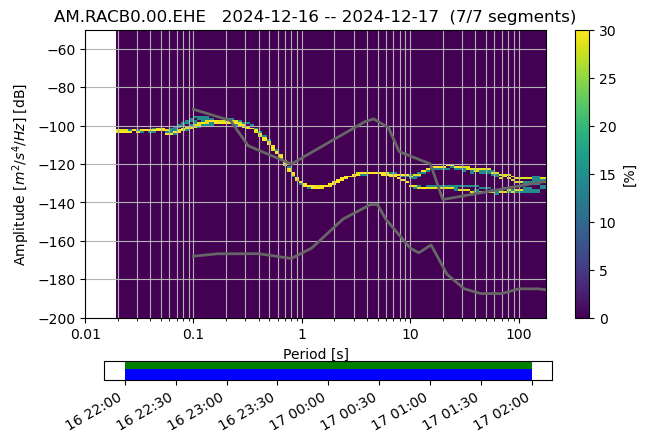

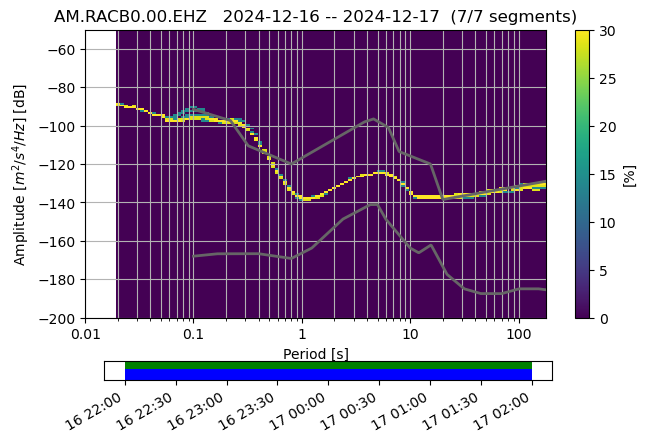

In [10]:
for tr in st_rasp:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_rasp)
    ppsd.add(tr)
    ppsd.plot()

In [11]:
st_rasp

2 Trace(s) in Stream:
AM.RACB0.00.EHE | 2024-12-16T21:59:59.997000Z - 2024-12-17T01:59:59.997000Z | 100.0 Hz, 1440001 samples
AM.RACB0.00.EHZ | 2024-12-16T21:59:59.997000Z - 2024-12-17T01:59:59.997000Z | 100.0 Hz, 1440001 samples

In [23]:
st0 = obs.Stream()

st0 += st_seis.copy().remove_response(inv_seis, output="ACC")
# st0 += st_tilt.copy()
st0 += st_rasp.copy().remove_response(inv_rasp, output="ACC")

In [24]:
st2 = st0.copy()

st2 = st2.detrend("demean")

st2 = st2.taper(0.01)

# st2 = st2.resample(1.0, no_filter=False)

fxx, pxx = __compare_psd_stream(st2, twin_sec=1800, psd="welch", plot=False)

# fxx, pxx = __compare_psd_stream(st2, n_win=10, time_bandwidth=3.5, psd="multitaper", plot=False)


In [25]:
models = np.load("/home/andbro/Documents/ROMY/LowNoiseModel/data/"+"noise_models.npz")

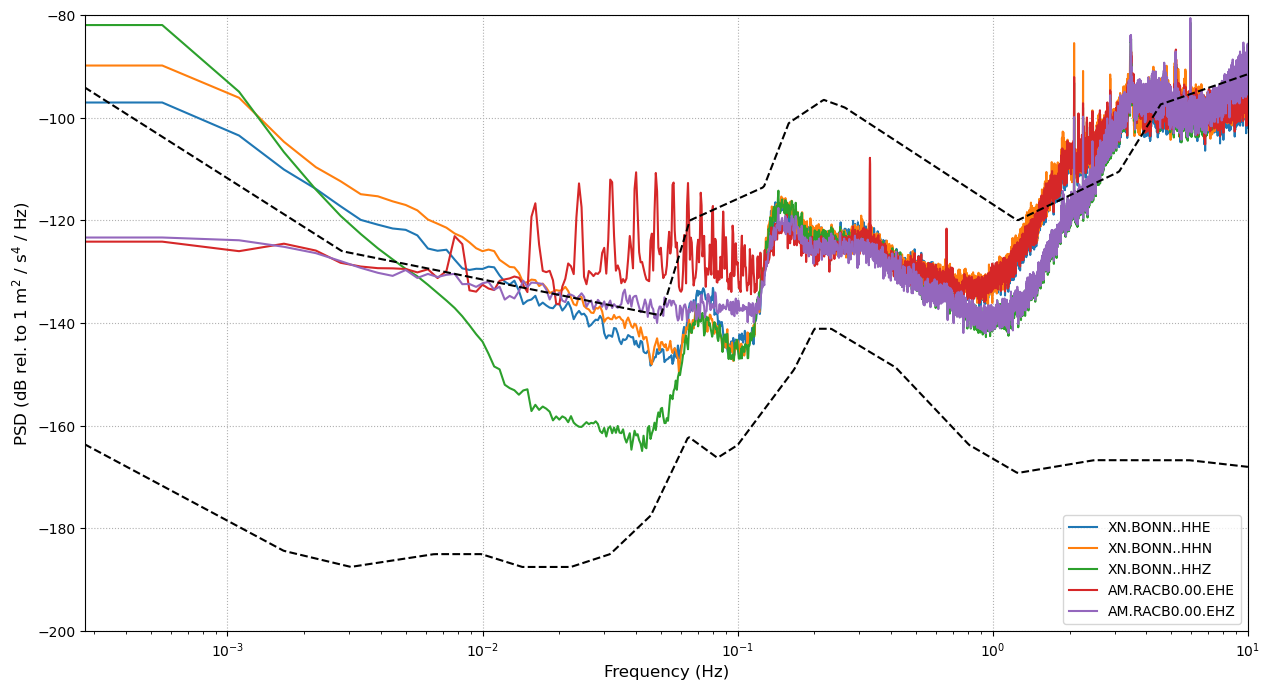

In [26]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2:

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

try:
    ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
    ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")
except:
    pass

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();